# Analysis of EG01-EG23 Cyclus scenario with Cymetric
Cymetric provides a python-based way to interact with your Cyclus SQLite 
output file. There are various "metrics" in Cymetric, which pull data from 
different tables in the output, and other metrics that combine tables 
to produce other metrics. 

The analysis problems explored in this workshop include:
* Visualizing the fuel cycle modeled in the scenario
* Plotting the number of reactors deployed against the 
  amount of electricity generated
* Plotting the amount of uranium sent to reactor types
* Calculating the activity of material sent to a waste facility. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cymetric as cym # Use an alias for cymetric
from cymetric import graphs

/root/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Open the output file with Cymetric
database = cym.dbopen('eg01-eg23.sqlite')
# Define the Evaluator Object 
eg23_evaluator = cym.Evaluator(database, write=False) #Don't write metrics to the database

## Visualize the fuel cycle scenario

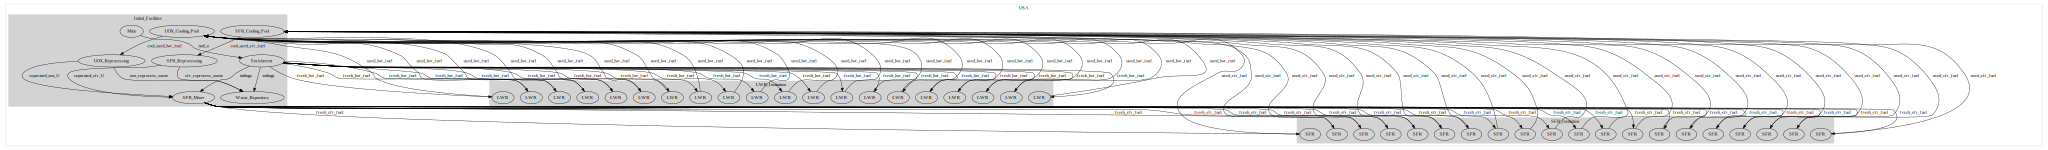

In [3]:
# Create a flow graph from the evaluator object
graphs.flow_graph(eg23_evaluator, label='comm')

In [4]:
# That ones looks a little messy, showing each of the reactor 
# agents as a sepearate node on the figure. The course instructors 
# created an even more simple fuel cycle to make this figure easier 
# to read. This figure is created from a separate output file, so 
# we need to open the new data base with Cymetric. 

# Do we want to just put in the image Dean generated, or create a graph 
# from a separate input file?

## Compare the number of reactors and the amount of electricity produced
We have different metrics we will look at for this: 
* `BuildSeries`, to get the number of reactors that are commissioned
* `DecommissionSeries`, to get the number of reactors that are decommissioned
* `MonthlyElectricityGeneratedByAgent`, to get the amount of electircity 
  generated by the reactors each year.

First, we will pull the `BuildSeries` metric, and sort out the data into the 
different prototypes. Second, we will pull the `DecommissionSeries` metric
and sort the data into different prototypes. Then, we will combine 
the `BuildSeries` and `DecommissionSeries` metrics to calculate the 
number of reactors deployed as a function of time. 

For the electricity generation data, we will pull the 
`MonthlyElectricityGeneratedByAgent` metric and sum the data across 
all agents to yield the total electircity generated as a function 
of timestep. 

Finally, we will plot both sets of data (the total number of reactors 
deployed and the electricity generated) on the same plot, using two 
different axes. 

In [5]:
# Get all BuildSeries data, then sort into LWR and SFR deployments
build_series = eg23_evaluator.eval('BuildSeries')
lwr_build = build_series.loc[build_series['Prototype'] == 'LWR']
sfr_build = build_series.loc[build_series['Prototype'] == 'SFR']

# Get the DecomSeries data, turn all of the decommission counts to 
# zero, then split by prototype. 
decom_series = eg23_evaluator.eval('DecommissionSeries')
lwr_decom = decom_series.loc[decom_series['Prototype'] == 'LWR']
sfr_decom = decom_series.loc[decom_series['Prototype'] == 'SFR']
# Multiply by negative one to count them as exiting the simulation
lwr_decom['Count'] *= -1
sfr_decom['Count'] *= -1

In [6]:
# Get a timeseries of the number of each reactor prototype 
# deployed in each time step. 
lwr_number = np.zeros(2000)
for variable in [lwr_build, lwr_decom]:
    for row in variable.itertuples():
        time_step = row[2]
        lwr_number[time_step:] += row[4]

sfr_number = np.zeros(2000)
for variable in [sfr_build, sfr_decom]:
    for row in variable.itertuples():
        time_step = row[2]
        sfr_number[time_step:] += row[4]
        
reactors_deployed = pd.DataFrame(data = {'Time': np.linspace(0,1999, 2000),
                                         'lwr':lwr_number,
                                         'sfr':sfr_number})

In [7]:
# Get electiricty generated and sum across time steps. 
all_electricity = eg23_evaluator.eval('MonthlyElectricityGeneratedByAgent')
summed_electricity = all_electricity[['Month', 'Energy']].groupby(by=['Month']).sum()

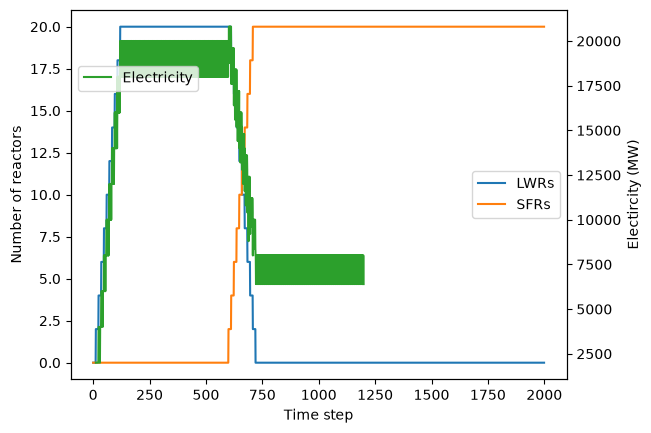

In [8]:
fig, ax1 = plt.subplots()

ax1.plot(reactors_deployed['Time'], reactors_deployed['lwr'])
ax1.plot(reactors_deployed['Time'], reactors_deployed['sfr'])
ax1.set_xlabel('Time step')
ax1.set_ylabel('Number of reactors')


ax2 = ax1.twinx()
ax2.plot(summed_electricity['Energy'], 
         color='tab:green')
ax2.set_ylabel('Electircity (MW)')

ax1.legend(['LWRs', 'SFRs'])
ax2.legend(['Electricity'], loc=(0.015, 0.78))

## Material transactions 
This section does analysis on the materials traded between 
facilities in the fuel cycle scenario. This analysis is done 
with the `TransactionQuantity` metric, which provides the mass 
of a commodity in each transaction. 

In [9]:
# Need to figure out exactly what we want to do with this one. 
trans_quantity = eg23_evaluator.eval('TransactionQuantity')
commodity_names = trans_quantity['Commodity'].unique()
commodity_trans ={}
for commodity_name in commodity_names:
    commodity_trans[commodity_name] = trans_quantity.loc[trans_quantity['Commodity'] == commodity_name]

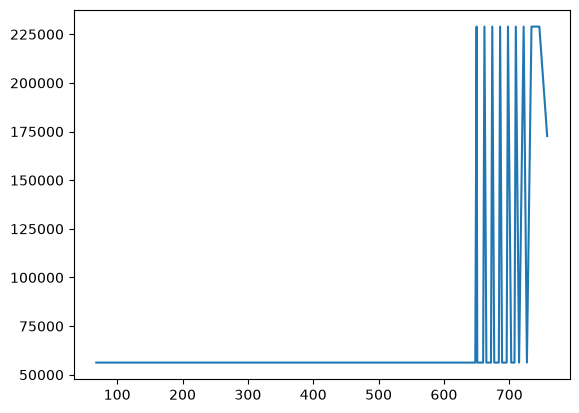

In [10]:
plt.plot(commodity_trans['separated_uox_U']['TimeCreated'],
         commodity_trans['separated_uox_U']['Quantity'])